### Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('./ctr.csv')
time = df['Time'].values
motor = df['Motor'].values
optenx = df['OptenX'].values
opteny = df['OptenY'].values
df

,Time,Motor,OptenX,OptenY
0,0.024919,0,0.015875,0.015875
1,0.057167,3,0.031750,0.000000
2,0.089082,12,0.111125,0.000000
3,0.121995,26,0.158750,0.015875
4,0.154908,44,0.301625,0.000000
...,...,...,...,...
855,28.055158,403,7.572375,0.158750
856,28.087073,403,7.572375,0.158750
857,28.118955,403,7.572375,0.158750
858,28.153212,403,7.572375,0.158750


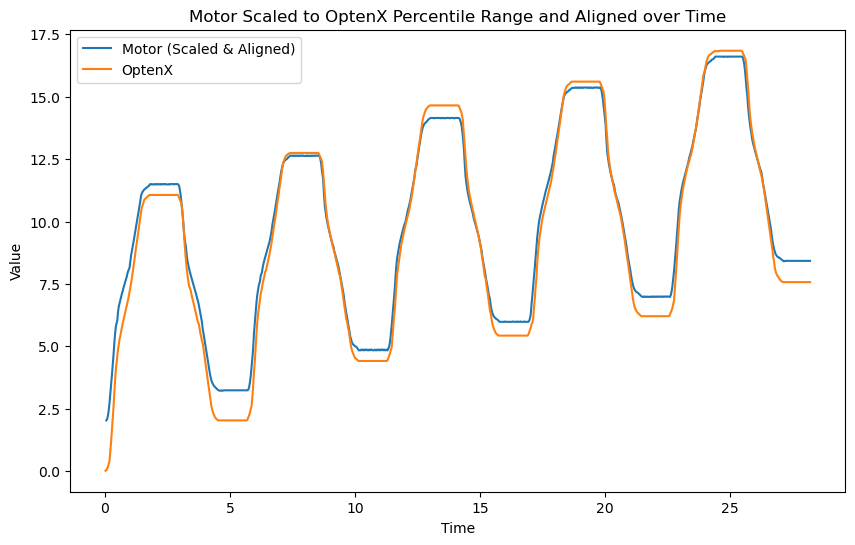

In [7]:
from scipy.signal import correlate

# Define percentiles for scaling range
lower_percentile = 5
upper_percentile = 95

# Compute percentiles for optenX
optenx_lower_bound = np.percentile(optenx, lower_percentile)
optenx_upper_bound = np.percentile(optenx, upper_percentile)

# Scale motor to the percentile range of optenX
motor_scaled = ((motor - np.min(motor)) / (np.max(motor) - np.min(motor))) * (optenx_upper_bound - optenx_lower_bound) + optenx_lower_bound

# Find lag
xcorr = correlate(motor_scaled, optenx, mode='full')
lag = np.argmax(xcorr) - (len(motor_scaled) - 1)

# Align motor_scaled by shifting
aligned_motor = np.roll(motor_scaled, -lag)
if lag > 0:
    aligned_motor = aligned_motor[:-lag]
    aligned_time = time[:-lag]
elif lag < 0:
    aligned_motor = aligned_motor[-lag:]
    aligned_time = time[-lag:]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(aligned_time, aligned_motor, label='Motor (Scaled & Aligned)')
plt.plot(time, optenx, label='OptenX')
plt.legend()
plt.title('Motor Scaled to OptenX Percentile Range and Aligned over Time')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

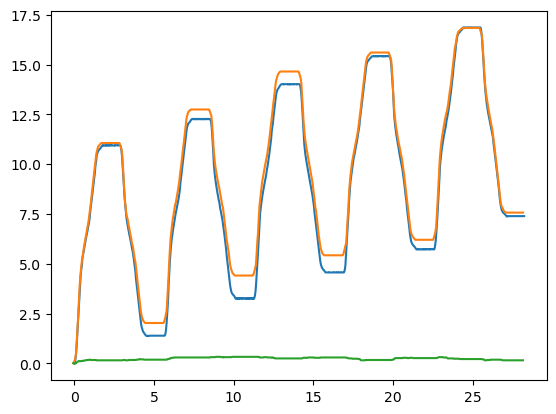

In [17]:
delay = 0.075
plt.plot(time, motor/54.5, label="Motor")
plt.plot(time-delay, optenx, label="Opten")
plt.plot(time-delay, opteny, label="Opten")